<h1>Why Do We Need Categorical Encoding</h1>

<p>Machine learning models are incredibly powerful at performing complex mathematics, but they have a major limatation: <b>they only understand numbers.</b> If you feed a machine learning algorithm a dataset with a column like "City" containing values like "New York," "London," and "Tokyo," the model will completely freeze. It does not know how to multiply or calculate the distance of the word "Tokyo."</p>

<p><b>Categorical Encoding</b> is simply the process of translating text-based categories into numbers so that the mathematical algorithms can read, process, and learn from them</p>

<h2>The Two Main Types of Categories</h2>

<p>Before we encode anything, we have to look at our text data and ask one critical question: Does this data have a natural, logical order? Based on your answer, you will choose one of two primary encoding techniques:</p>

<ol>
    <li><b>Ordinal Encoding (When Order Matters)</b></li>
    <p>Use this when your categories have a clear, mathematical hierarchy or ranking. For example: customer review - Poor, Fair, Good, Excellent</p>

  <b>How it works:</b> we simply assign an integer to each category, making sure the numbers reflect the logical order

  <li><b>One-Hot Encoding (When Order Does NOT Matter)</li>
  <p>Use this for nominal data - categories where no single item is "greater than" or "higher than" another. For example: colors - Red, Blue, Green</p>

  <b>The Danger of Ordinal Encoding Here:</b> if we assign Red = 0, Blue = 1, and Green = 2, the model would look at the math and falsely assume that Green is somehow "twice as big" as Blue, or that Red + Blue = Green. This would ruin your modle's logic!

  <b>How One-Hot Encoding works:</b> instead of assigning a single number, we take the original column and split it into multiple new columns (one for each unique category). We then use <b>1s and 0s</b> to indicate whether that category is present
    
</ol>

In [1]:
import numpy as np

<h2>Ordinal Encoding From Scratch</h2>

In [2]:
class CustomOrdinalEncoder:
    def __init__(self, category_order):
        # We initialize the class with the strict, logical hierarchy
        
        self.category_order = category_order
        self.mapping_dict_ = {}

    def fit(self, X):
        # Build the translation dictionary
        # enumerate() automatically gives us an index (0, 1, 2...) for each item
        
        for index, category in enumerate(self.category_order):
            self.mapping_dict_[category] = index

        return self

    def transform(self, X):
        # Create a copy of the data so we don't accidentally overwrite the original
        X_encoded = X.copy()

        # Loop through the dataset and replace text with numbers
        for i in range(len(X_encoded)):
            category = X_encoded[i]

            if category in self.mapping_dict_:
                X_encoded[i] = self.mapping_dict_[category]

            else:
                # A safety net for unexpected or missing categories
                X_encoded[i] = -1

        # Return the data as an array of integers
        return X_encoded.astype(int)

    def fit_transform(self,X):
        return self.fit(X).transform(X)
    

In [3]:
# 1. Our raw text dataset
t_shirt_sizes = np.array(['Medium', 'Small', 'Large', 'Small', 'Extra Large', 'Medium'])

# 2. Define the strict mathematical order from smallest to largest
size_hierarchy = ['Small', 'Medium', 'Large', 'Extra Large']

# 3. Instantiate our custom encoder
encoder = CustomOrdinalEncoder(category_order = size_hierarchy)

# 4. Fit and transform the data
encoded_sizes = encoder.fit_transform(t_shirt_sizes)

print(f"Original Data: {t_shirt_sizes}")
print(f"Encoded Data:  {encoded_sizes}")

Original Data: ['Medium' 'Small' 'Large' 'Small' 'Extra Large' 'Medium']
Encoded Data:  [1 0 2 0 3 1]


<h2>Using Scikit-learn</h2>

In [4]:
from sklearn.preprocessing import OrdinalEncoder
# 1. Our raw dataset
# We use .reshape(-1, 1) to convert our flat list into a 2D column (rows, 1 column)
t_shirt_sizes = np.array(['Medium', 'Small', 'Large', 'Small', 'Extra Large', 'Medium']).reshape(-1, 1)

# 2. Define the strict mathematical order
# Notice the double brackets! This tells the encoder: "Here is the hierarchy for the first column."
size_hierarchy = [['Small', 'Medium', 'Large', 'Extra Large']]

# 3. Instantiate the industry-standard encoder
# We pass our custom order into the 'categories' parameter
encoder = OrdinalEncoder(categories = size_hierarchy)

# 4. Fit and transform the data in one step
sizes_encoded = encoder.fit_transform(t_shirt_sizes)

print("Original Data (2D Column):")
print(t_shirt_sizes)
print("\nEncoded Data:")
print(sizes_encoded)

Original Data (2D Column):
[['Medium']
 ['Small']
 ['Large']
 ['Small']
 ['Extra Large']
 ['Medium']]

Encoded Data:
[[1.]
 [0.]
 [2.]
 [0.]
 [3.]
 [1.]]


<h3>Working with a real dataset</h3>

In [5]:
import pandas as pd

In [6]:
df = pd.read_csv('customer.csv')
print('Column Names:')
print(df.columns.tolist())

print()
print(df.sample(5))
print()
print(df.isnull().sum())
print()


review_hierarchy = ['Poor', 'Average', 'Good']
education_hierarchy = ['School', 'UG', 'PG']

all_hierarchies = [review_hierarchy, education_hierarchy]

# Isolate the  specific ordinal columns
target_columns = ['review', 'education']

encoder = OrdinalEncoder(categories = all_hierarchies)
encoder.set_output(transform = 'pandas')

# 3. Fit and Transform
df[target_columns] = encoder.fit_transform(df[target_columns])

# View the output!
df.sample(5)

Column Names:
['age', 'gender', 'review', 'education', 'purchased']

    age  gender   review education purchased
21   32    Male  Average        PG        No
49   25  Female     Good        UG        No
41   23    Male     Good        PG       Yes
36   34  Female     Good        UG       Yes
16   59    Male     Poor        UG       Yes

age          0
gender       0
review       0
education    0
purchased    0
dtype: int64



,age,gender,review,education,purchased
20,57,Female,1.0,0.0,Yes
5,31,Female,1.0,0.0,Yes
21,32,Male,1.0,2.0,No
23,96,Female,2.0,0.0,No
28,48,Male,0.0,0.0,No


<h2>Label Encoder</h2>
<p>Both OrdinalEncoder and LabelEncoder do the exact same fundamental math: they look at text categories and map them to numbers (0, 1, 2, etc.).

The difference is strictly about where you are allowed to use them according to the scikit-learn architectural blueprint:</p>
<ol>
    <li<><b>OrdinalEncoder</b> is for your Features (X): It expects 2D data (like a spreadsheet with multiple columns). It is built to handle multiple columns at once (like education and review).</li>
    <li><b>LabelEncoder</b> is strictly for your Target (y): It expects 1D data (a single, flat list or a single column). It is designed to encode the answer key you are trying to predict.</li>
</ol>

In [7]:
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('customer.csv')

# target column
y = df['purchased']

le = LabelEncoder()
y_encoded = le.fit_transform(y)


print("Original Target (y):")
print(y.head().tolist())

print("\nEncoded Target (y):")
print(y_encoded[:5])

Original Target (y):
['No', 'No', 'No', 'No', 'No']

Encoded Target (y):
[0 0 0 0 0]


In [8]:
le.classes_

array(['No', 'Yes'], dtype=object)

<h1>One Hot Encodig</h1>
<p>One-Hot Encoding is a data preprocessing technique used to convert categorical data into a numerical format that machine learning models can understand. It creates separate binary columns for each category, where 1 represents the presence of a category and 0 represents its absence.</p>

<ul>
    <li>Converts categorical values into binary columns</li>
    <li>Prevents models from assuming an incorrect order between categories</li>
    <li>Improves machine learning model performance</li>
    <li>Helps capture relationships between categorical features</li>
    <li>Required for many machine learning algorithms that accept numerical input only</li>
</ul>

<h2>Working of One Hot Encoding</h2>
<p>One-Hot Encoding creates a separate column for each category in the dataset. In the fruit example, when the fruit is Apple, the Fruit_Apple column gets the value 1 while the other fruit columns contain 0. Similarly, for Mango and Orange, their respective columns contain 1 and the remaining columns contain 0.</p>

<ul>
    <li>Each category gets its own binary column</li>
    <li>1 indicates the presence of a category</li>
    <li>0 indicates the absence of a category</li>
    <li>Converts categorical values into numerical format for machine learning models</li>
</ul>

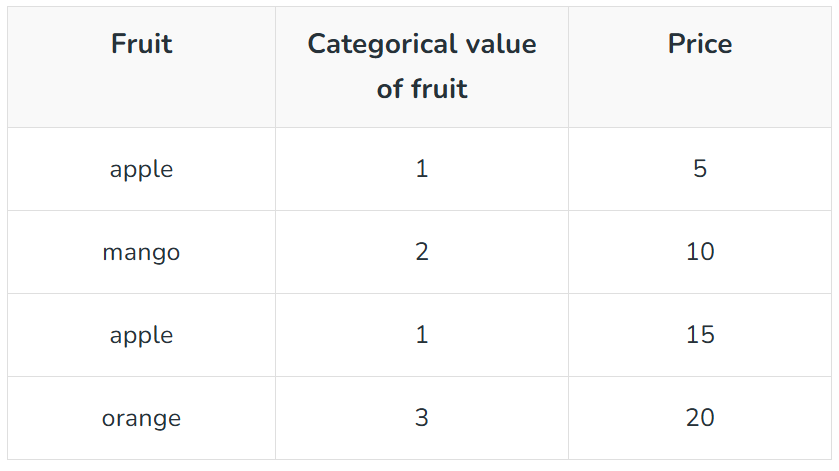

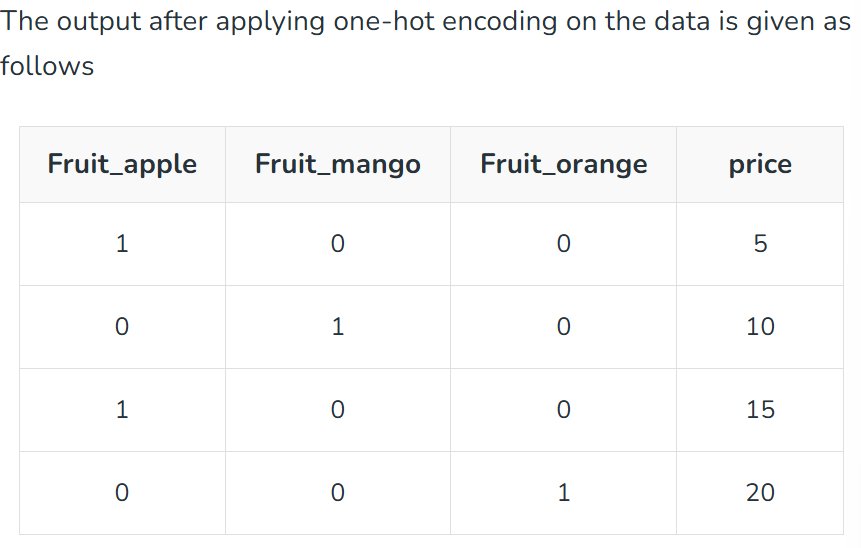

<h3>From Scratch</h3>

In [9]:
class CustomOneHotEncoder:
    def __init__(self):
        # this will store our unique categories (e.g., ['female', 'male'])
        self.unique_categories_ = []

    def fit(self, X_column):
        # find all unique values in the column using Python's set()
        # sort them alphabetically so our columns are always in a predictable order
        self.unique_categories_ = sorted(list(set(X_column)))

        return self


    def transform(self, X_column):
        # this will hold our final matrix of 1s and 0s
        encoded_data = []

        # loop through every single row in the data
        for item in X_column:
            # create a row of all zeros (e.g., [0.0 0.0])
            row = [0.0] * len(self.unique_categories_)

            # find the index of our current item, if it is 'male'
            # we find where 'male' sits in our unique list, and flip that 0 to 1.0
            if item in self.unique_categories_:
                index_to_flip = self.unique_categories_.index(item)
                row[index_to_flip] = 1.0

            # add this finished row to our new data matrix
            encoded_data.append(row)

        return encoded_data

    def fit_transform(self,X_column):
        return self.fit(X_column).transform(X_column)

In [10]:
# the raw text data from your dataset
gender_column = ['Male', 'Male', 'Female', 'Female', 'Male']

# initiate our custom engine
encoder = CustomOneHotEncoder()

# fit and transform the data
encoded_output = encoder.fit_transform(gender_column)

# format it beautifully using Pandas so we can read it easily
# we dynamically generate column names like "gender_Female" and "gender_Male"
column_names = [f'gender_{cat}' for cat in encoder.unique_categories_]
df_encoded = pd.DataFrame(encoded_output, columns=column_names)

print("--- Custom One-Hot Encoded Output ---")
df_encoded

--- Custom One-Hot Encoded Output ---


,gender_Female,gender_Male
0,0.0,1.0
1,0.0,1.0
2,1.0,0.0
3,1.0,0.0
4,0.0,1.0


<h2>Using Scikit-learn</h2>

In [15]:
from sklearn.preprocessing import OneHotEncoder

df = pd.read_csv('customer.csv')
df = df.dropna(subset = ['gender'])

target_column = df[['gender']]
encoder = OneHotEncoder(sparse_output = False)
encoder.set_output(transform = 'pandas')

encoded_gender = encoder.fit_transform(target_column)


# the stiching process
df_combined = pd.concat([df, encoded_gender], axis = 1)

df_final = df_combined.drop('gender', axis = 1)

df_final.sample(10)

,age,review,education,purchased,gender_Female,gender_Male
15,75,Poor,UG,No,0.0,1.0
29,83,Average,UG,Yes,1.0,0.0
49,25,Good,UG,No,1.0,0.0
32,92,Average,UG,Yes,0.0,1.0
12,51,Poor,School,No,0.0,1.0
27,69,Poor,PG,No,1.0,0.0
7,60,Poor,School,Yes,1.0,0.0
33,89,Good,PG,Yes,1.0,0.0
2,70,Good,PG,No,1.0,0.0
20,57,Average,School,Yes,1.0,0.0


<h3>The Dummy Variable Trap</h3>
<p>If you look closely at our final output, the <b>gender_Female</b> and <b>gender_Male</b> columns are technically providing the exact same information. If gender_Female is 1.0, we already know gender_Male absolutely must be 0.0</p>

<p>Feeding this redundant information into a machine learning model causes a catastrophic mathematical error known as the <b>Dummy Variable Trap</b></p>

<h3>The Rule of N - 1</h3>
<p>To defeat the trap, Data Scientists use a very simple rule: Always drop one of the One-Hot Encoded columns. If you have N categories, you only need N - 1 columns to represent them</p>

<ul>
    <li>For 2 categories (Male, Female): We only need 1 column (e.g., gender_Male). If it's 1, they are Male. If it's 0, the model instantly knows they are Female.</li>
    <li>For 3 categories (Red, Blue, Green): We only need 2 columns (e.g., Color_Blue, Color_Green). If both of those are 0, the model instantly knows the color must be Red!</li>
</ul>

In [22]:
from sklearn.preprocessing import OneHotEncoder

df = pd.read_csv('customer.csv')
df = df.dropna(subset = ['gender'])

target_column = df[['gender']]
encoder = OneHotEncoder(sparse_output = False, drop='first')
encoder.set_output(transform = 'pandas')

encoded_gender = encoder.fit_transform(target_column)


# the stiching process
df_combined = pd.concat([df, encoded_gender], axis = 1)

df_final = df_combined.drop('gender', axis = 1)

df_final.sample(10)

,age,review,education,purchased,gender_Male
43,27,Poor,PG,No,1.0
44,77,Average,UG,No,0.0
45,61,Poor,PG,Yes,1.0
13,57,Average,School,No,0.0
20,57,Average,School,Yes,0.0
7,60,Poor,School,Yes,0.0
47,38,Good,PG,Yes,0.0
33,89,Good,PG,Yes,0.0
1,68,Poor,UG,No,0.0
36,34,Good,UG,Yes,0.0


<h3>Using Pandas</h3>

In [23]:
import numpy as np

In [24]:
df = pd.read_csv('cars.csv')
df.sample(10)

,brand,km_driven,fuel,owner,selling_price
7475,Volkswagen,60000,Petrol,First Owner,400000
479,Hyundai,50000,Petrol,First Owner,229999
6256,Maruti,50800,Petrol,Second Owner,110000
3231,Maruti,35000,Diesel,First Owner,675000
6862,Tata,40000,Petrol,First Owner,520000
2268,Maruti,100000,Diesel,First Owner,775000
1509,Maruti,60000,Petrol,Second Owner,185000
393,Hyundai,70000,Diesel,Third Owner,535000
1599,Mahindra,120000,Diesel,First Owner,450000
54,Honda,63000,Diesel,First Owner,525000


In [26]:
df['fuel'].value_counts()

fuel
Diesel    4402
Petrol    3631
CNG         57
LPG         38
Name: count, dtype: int64

In [27]:
df['owner'].value_counts()

owner
First Owner             5289
Second Owner            2105
Third Owner              555
Fourth & Above Owner     174
Test Drive Car             5
Name: count, dtype: int64

In [28]:
pd.get_dummies(df, columns = ['fuel', 'owner'])

,brand,km_driven,selling_price,fuel_CNG,fuel_Diesel,fuel_LPG,fuel_Petrol,owner_First Owner,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,Maruti,145500,450000,False,True,False,False,True,False,False,False,False
1,Skoda,120000,370000,False,True,False,False,False,False,True,False,False
2,Honda,140000,158000,False,False,False,True,False,False,False,False,True
3,Hyundai,127000,225000,False,True,False,False,True,False,False,False,False
4,Maruti,120000,130000,False,False,False,True,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
8123,Hyundai,110000,320000,False,False,False,True,True,False,False,False,False
8124,Hyundai,119000,135000,False,True,False,False,False,True,False,False,False
8125,Maruti,120000,382000,False,True,False,False,True,False,False,False,False
8126,Tata,25000,290000,False,True,False,False,True,False,False,False,False


<h3>N - 1 One Hot Encoding</h3>

In [30]:
pd.get_dummies(df, columns = ['fuel', 'owner'], drop_first=True)

,brand,km_driven,selling_price,fuel_Diesel,fuel_LPG,fuel_Petrol,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,Maruti,145500,450000,True,False,False,False,False,False,False
1,Skoda,120000,370000,True,False,False,False,True,False,False
2,Honda,140000,158000,False,False,True,False,False,False,True
3,Hyundai,127000,225000,True,False,False,False,False,False,False
4,Maruti,120000,130000,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
8123,Hyundai,110000,320000,False,False,True,False,False,False,False
8124,Hyundai,119000,135000,True,False,False,True,False,False,False
8125,Maruti,120000,382000,True,False,False,False,False,False,False
8126,Tata,25000,290000,True,False,False,False,False,False,False


<h3>Using Scikit-learn</h3>

In [31]:
df.sample(10)

,brand,km_driven,fuel,owner,selling_price
1913,Mahindra,100000,Diesel,First Owner,450000
6624,Mahindra,120000,Diesel,First Owner,750000
6149,Mahindra,60000,Diesel,First Owner,1250000
5301,Maruti,50000,Petrol,First Owner,482000
7982,Maruti,90000,Petrol,Second Owner,45957
7738,Maruti,10000,Petrol,First Owner,390000
2074,Nissan,35000,Diesel,First Owner,800000
1228,Maruti,72000,Petrol,First Owner,310000
6760,Datsun,70000,Petrol,Second Owner,325000
3635,Hyundai,50000,Petrol,First Owner,500000


In [32]:
from sklearn.model_selection import train_test_split

In [35]:
X = df.drop('selling_price', axis = 1)
y = df['selling_price']

In [39]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2, random_state = 42)

In [41]:
X_train.shape, X_test.shape

((6502, 4), (1626, 4))

In [49]:
enocder = OneHotEncoder(drop = 'first',sparse_output=False)
X_train_encoded = encoder.fit_transform(X_train[['fuel','owner']])

In [51]:
X_test_encoded = encoder.transform(X_train[['fuel','owner']])

In [52]:
X_train_encoded.shape, X_test_encoded.shape

((6502, 7), (6502, 7))

In [59]:
pd.concat([X_train[['brand','km_driven']], X_train_encoded], axis = 1)

,brand,km_driven,fuel_Diesel,fuel_LPG,fuel_Petrol,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
6518,Tata,2560,0.0,0.0,1.0,0.0,0.0,0.0,0.0
6144,Honda,80000,0.0,0.0,1.0,0.0,1.0,0.0,0.0
6381,Hyundai,150000,1.0,0.0,0.0,1.0,0.0,0.0,0.0
438,Maruti,120000,1.0,0.0,0.0,0.0,1.0,0.0,0.0
5939,Maruti,25000,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
5226,Mahindra,120000,1.0,0.0,0.0,0.0,0.0,0.0,0.0
5390,Maruti,80000,1.0,0.0,0.0,0.0,1.0,0.0,0.0
860,Hyundai,35000,0.0,0.0,1.0,0.0,0.0,0.0,0.0
7603,Maruti,27000,1.0,0.0,0.0,0.0,0.0,0.0,0.0


<h2>One Hot Encoding with Top Categories</h2>

In [63]:
counts = df['brand'].value_counts()
counts

brand
Maruti           2448
Hyundai          1415
Mahindra          772
Tata              734
Toyota            488
Honda             467
Ford              397
Chevrolet         230
Renault           228
Volkswagen        186
BMW               120
Skoda             105
Nissan             81
Jaguar             71
Volvo              67
Datsun             65
Mercedes-Benz      54
Fiat               47
Audi               40
Lexus              34
Jeep               31
Mitsubishi         14
Land                6
Force               6
Isuzu               5
Ambassador          4
Kia                 4
MG                  3
Daewoo              3
Ashok               1
Opel                1
Peugeot             1
Name: count, dtype: int64

In [68]:
df['brand'].nunique()

32

In [73]:
# now we will set a threshold value so that the brand under that theshold will be considered as 'other'
threshold = 100
repl = counts[counts <= threshold].index

In [76]:
pd.get_dummies(df['brand'].replace(repl, 'other'), drop_first = True).sample(10)

,Chevrolet,Ford,Honda,Hyundai,Mahindra,Maruti,Renault,Skoda,Tata,Toyota,Volkswagen,other
4905,False,False,False,False,False,True,False,False,False,False,False,False
7461,False,False,False,False,False,False,False,False,True,False,False,False
2812,False,False,True,False,False,False,False,False,False,False,False,False
5969,False,False,False,False,False,True,False,False,False,False,False,False
6909,True,False,False,False,False,False,False,False,False,False,False,False
7924,False,False,False,False,False,True,False,False,False,False,False,False
2416,False,False,False,False,True,False,False,False,False,False,False,False
2747,False,False,False,False,False,True,False,False,False,False,False,False
2462,False,False,False,False,True,False,False,False,False,False,False,False
7735,False,False,False,False,False,True,False,False,False,False,False,False
